In [59]:
%load_ext autoreload
%autoreload 2
from PyPDF2 import PdfReader
import os
import amrlib
import penman
import torch
from amrlib import load_stog_model
import networkx as nx
import sys, os
from pyvis.network import Network
import matplotlib.pyplot as plt
import amrlib
import spacy
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from kg.formatting.formatting_manager import FormattingManager
import sys, importlib,os
sys.modules.pop('PatentTextFormatter', None)
importlib.invalidate_caches()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
import torch, os, platform

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)   # None == CPU-only build
print("gpu count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("name[0]:", torch.cuda.get_device_name(0))
    print("capability[0]:", torch.cuda.get_device_capability(0))
else:
    print("No CUDA device visible to PyTorch.")

torch: 2.7.1+cu128
cuda available: True
torch.version.cuda: 12.8
gpu count: 1
name[0]: NVIDIA GeForce RTX 5070 Ti
capability[0]: (12, 0)


In [61]:
formatterManager = FormattingManager()
segment_split = formatterManager.split_segments("A computing apparatus configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks based on predictive workload analysis, wherein said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.")
print("split" + str(segment_split))

split['A computing apparatus configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks based on predictive workload analysis, wherein said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.']


In [62]:
nlp = spacy.load("en_core_web_sm")
formatterManager = FormattingManager()
sentence_split = [[]]
for i in range(0,len(segment_split)):
    doc = nlp(segment_split[i])
    sentences = [sent.text.strip() for sent in doc.sents]
    sentence_str = ""
    for c in sentences:
        sentence_split[i].extend(formatterManager.split(c))

print(sentence_split[0])



State
Raw: ```json
[
  "A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.",
  "The allocation is based on predictive workload analysis.",
  "Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints."
]
``` State: {'text': 'A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks. Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', 'sentences': ['A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', 'The allocation is based on predictive workload analysis.', 'Said allocation is continuously optimized through feedback derived from real-time performance metrics and late

In [63]:
rule_based = [[]]
for i, c in enumerate(sentence_split):
    for d in c:
        print("Snip " + d.text)
        rule = formatterManager.rule_standardiser(
            d.text
        )
        rule_based[i].append(rule[i].text)  # replace the old element
print(sentence_split)
print(rule_based[0])


        



Snip A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.
Run sentence simplifier
Snip The allocation is based on predictive workload analysis.
Run sentence simplifier
Snip Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.
Run sentence simplifier
[[Sentence(text='A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', index=0, source='', span=None, id='87d706c2-64ba-4733-a389-01216f560160', kg_node_id=None, embedding=None, tokens=[], entities=[], tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The allocation is based on predictive workload analysis.', index=1, source='', span=None, id='f2823e03-6e3f-41a3-b4bf-ee15617aec89', kg_node_id=None, embedding=None, tokens=[], entities=[], tags=[], im

In [64]:
print(rule_based[0][1])
for c,i in enumerate(rule_based):
    for i in rule_based[c]:
        simplify = formatterManager.simplify(i)
        print(simplify)



[GENERIC] Predictive workload analysis determines the allocation.
['a', 'computing', 'apparatus', 'dynamically', 'allocate', 'processing', 'resource', 'among', 'a', 'plurality', 'of', 'concurrent', 'machine', '-', 'learn', 'inference', 'task', '.']
['[', 'generic', ']', 'predictive', 'workload', 'analysis', 'determine', 'the', 'allocation', '.']
['[', 'assumption', ']', 'the', 'system', 'continuously', 'optimize', 'say', 'allocation', 'through', 'feedback', 'derive', 'from', 'real', '-', 'time', 'performance', 'metric', 'and', 'latency', 'constraint', '.']


In [65]:
amrlib.__file__
stog = amrlib.load_stog_model()


In [102]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the AMR model and move to GPU
stog = amrlib.load_stog_model()
if torch.cuda.is_available():
    stog.model.to('cuda')
    stog.device = torch.device('cuda')
else:
    stog.device = torch.device('cpu')

sentences = [
    'Caleb is 21',
    'Caleb lives in Munich',
    'Caleb was born in Berlin',
    'Nathan lives in Marburg',
    'Nathan and Caleb are brothers',
    'Emma is 19',
    'Emma studies biology',
    'Emma lives in Berlin',
    'Caleb and Emma are friends',
    'Nathan studies engineering',
    'Caleb works at a bookstore',
    'Emma likes music',
    'Nathan likes football',
    'Caleb and Nathan play football together',
    'Emma has a cat',
    'Caleb likes Emma’s cat',
    'Nathan has a dog',
    'Caleb and Nathan walk the dog on weekends',
    'Emma and Caleb go to concerts',
    'Caleb’s favorite band is Coldplay',
    'Emma studies at Humboldt University',
    'Nathan studies at Marburg University',
    'Caleb visits Nathan in Marburg',
    'Emma and Nathan met last summer',
    'Emma and Caleb met at school',
    'Caleb’s mother is a teacher',
    'Nathan’s father is a doctor',
    'Emma’s brother is 15',
    'Caleb and Nathan grew up in Berlin',
    'Caleb moved to Munich last year',
    'Nathan stayed in Marburg for his studies',
    'Emma and Nathan text often',
    'Caleb calls Emma on weekends',
    'Nathan and Caleb visit their parents in Berlin',
    'Emma likes to travel',
    'Caleb wants to visit Paris',
    'Nathan visited Paris last year',
    'Emma and Caleb plan to visit Paris together',
    'Caleb likes coffee',
    'Emma prefers tea',
    'Nathan drinks tea in the morning',
    'Caleb and Nathan share an apartment in summer',
    'Emma comes over for dinner sometimes',
    'Caleb cooks pasta often',
    'Nathan helps with dishes',
    'Emma brings dessert',
    'Caleb and Emma take photos together',
    'Nathan posts photos on social media',
    'Emma studies every morning',
    'Caleb goes jogging in the park',
    'Nathan rides his bike to university'
]
graphs = stog.parse_sents(sentences)
for graph in graphs:
    print(graph)
sentences_g = list()
for i in graphs: 
    sentences_g.append(penman.decode(i))


# ::snt Caleb is 21
(a / age-01
      :ARG1 (p / person
            :name (n / name
                  :op1 "Caleb"))
      :ARG2 (t / temporal-quantity
            :quant 21
            :unit (y / year)))
# ::snt Caleb lives in Munich
(l / live-01
      :ARG0 (p / person
            :name (n / name
                  :op1 "Caleb"))
      :location (c / city
            :name (n2 / name
                  :op1 "Munich")))
# ::snt Caleb was born in Berlin
(b / bear-02
      :ARG1 (p / person
            :name (n / name
                  :op1 "Caleb"))
      :location (c / city
            :name (n2 / name
                  :op1 "Berlin")))
# ::snt Nathan lives in Marburg
(l / live-01
      :ARG0 (p / person
            :name (n / name
                  :op1 "Nathan"))
      :location (c / city
            :name (n2 / name
                  :op1 "Marburg")))
# ::snt Nathan and Caleb are brothers
(h / have-rel-role-91
      :ARG0 (p / person
            :name (n / name
                  :op1

In [105]:
# Minimal, commented AMR -> NetworkX merger with deep-literal collapsing
import re
import networkx as nx
from uuid import uuid4

nx_graph = nx.MultiDiGraph()

# Global registries
ENTITY_REGISTRY = {}    # identity_key -> global node id (concept nodes)
LITERAL_REGISTRY = {}   # literal_value -> node id (literal nodes)

def add_node_if_missing(gx, n, concept, kind="concept", **attrs):
    """Create node once with basic styling attrs."""
    if not gx.has_node(n):
        gx.add_node(n, concept=(None if concept is None else str(concept)),
                    kind=kind, **attrs)

# ---------- AMR helpers ----------

def strip_quotes(s: str) -> str:
    s = str(s)
    if len(s) >= 2 and s[0] == '"' and s[-1] == '"':
        return s[1:-1]
    return s

def normalize_literal(val: str) -> str:
    v = strip_quotes(val)
    v = re.sub(r'\s+', ' ', v).strip().lower()
    return v

def instance_vars_of(g):
    """All AMR variables that have :instance (i.e., concept nodes)."""
    return {s for s, r, t in g.triples if r == ":instance"}

def concept_of(g, v):
    return next((t for s, r, t in g.triples if s == v and r == ":instance"), None)

def wiki_of(g, v):
    w = next((t for s, r, t in g.triples if s == v and r == ":wiki"), None)
    if w is None:
        return None
    w = strip_quotes(w)
    return None if w == "-" else w

def name_tokens(g, v):
    """
    v --:name--> n ; n --:op1/2/3...--> "Tokens" (ordered)
    Returns list[str] or None.
    """
    name_nodes = [t for s, r, t in g.triples if s == v and r == ":name"]
    for n in name_nodes:
        ops = []
        for s2, r2, t2 in g.triples:
            if s2 == n and r2.startswith(":op") and r2[3:].isdigit():
                ops.append((int(r2[3:]), strip_quotes(t2)))
        if ops:
            ops.sort(key=lambda x: x[0])
            return [tok for _, tok in ops]
    return None

def name_op1_of(g, v):
    toks = name_tokens(g, v)
    if not toks:
        return None
    return normalize_literal(toks[0])

def identity_key_for_entity(g, v, include_concept=True):
    """
    Prefer :wiki; else normalized :name; optionally append instance type.
    Deterministic key for cross-sentence merging.
    """
    w = wiki_of(g, v)
    if w:
        base = f"wiki::{w}"
    else:
        toks = name_tokens(g, v)
        if toks:
            norm = " ".join(normalize_literal(t) for t in toks if normalize_literal(t))
            if norm:
                base = f"name::{norm}"
            else:
                return None
        else:
            return None
    if include_concept:
        c = concept_of(g, v)
        if c:
            base = f"{base}::type::{c}"
    return base

def simple_name_alias(g, v):
    """Very loose alias: first token of the name."""
    nm = name_op1_of(g, v)
    if not nm:
        return None
    first = nm.split()[0]
    return f"alias::{first}" if first else None

# ---------- Deep literal collapsing ----------

def deep_literal_label(g, v):
    """
    If v has a deep literal representation, return it as a string:
      - name ops → "Caleb" / "New York City"
      - quantities → "21 year"
    Else None.
    """
    # Names
    toks = name_tokens(g, v)
    if toks:
        return " ".join(toks)

    # Quantities: v --:quant 21 ; v --:unit--> u (u may itself have name)
    q = next((t for s, r, t in g.triples if s == v and r == ":quant"), None)
    if q is not None:
        q_str = strip_quotes(str(q))
        unit_nodes = [t for s, r, t in g.triples if s == v and r == ":unit"]
        if unit_nodes:
            u = unit_nodes[0]
            # Try to resolve unit to a readable label (name tokens, else concept)
            ulab = deep_literal_label(g, u)
            if not ulab:
                uc = concept_of(g, u)
                ulab = uc if uc else ""
            ulab = ulab.strip()
            return f"{q_str} {ulab}".strip()
        return q_str

    return None

def literal_node_id(gx, prefix, value):
    """Reuse a single literal node per distinct value across the whole graph."""
    key = value
    if key in LITERAL_REGISTRY:
        return LITERAL_REGISTRY[key]
    nid = f"{prefix}lit_{uuid4().hex[:8]}"
    add_node_if_missing(gx, nid, value, kind="literal", value=value)
    LITERAL_REGISTRY[key] = nid
    return nid

# ---------- AMR -> NX with merging + collapsing ----------

def amr_to_nx(g, gx, graph_id="g0", prefix="g0__"):
    """
    Build/extend gx with one AMR graph g.
    - Merge concept vars across sentences via identity keys (wiki/name/alias).
    - Redirect edges to deepest literals where possible (names, quantities).
    - Otherwise, keep concept-to-concept edges (namespaced).
    """
    inst = instance_vars_of(g)
    id_map = {}

    def glob(local_v):            # namespaced fallback for non-merged vars
        return f"{prefix}{local_v}"

    def ensure_concept_node(gid, v):
        add_node_if_missing(gx, gid, concept_of(g, v), kind="concept", graph_id=graph_id)

    # Assign global IDs for each instance var (merge if identity known)
    for v in inst:
        k_strict = identity_key_for_entity(g, v, include_concept=True)
        k_loose  = identity_key_for_entity(g, v, include_concept=False)
        k_alias  = simple_name_alias(g, v)

        # Reuse existing gid if any key is already registered
        existing_gid = None
        for k in (k_strict, k_loose, k_alias):
            if k and k in ENTITY_REGISTRY:
                existing_gid = ENTITY_REGISTRY[k]
                break

        # Else create new gid from the best available key, else namespaced
        if existing_gid is None:
            chosen_key = k_strict or k_loose or k_alias
            if chosen_key:
                existing_gid = f"ent::{chosen_key}"
            else:
                existing_gid = glob(v)

        # Register all available keys to the same gid (prevents future splits)
        for k in (k_strict, k_loose, k_alias):
            if k:
                ENTITY_REGISTRY[k] = existing_gid

        id_map[v] = existing_gid
        ensure_concept_node(existing_gid, v)

    # Add edges, collapsing targets to deep literals when available
    for src, role, tgt in g.triples:
        if role == ":instance":
            continue

        gsrc = id_map.get(src, glob(src))

        if tgt in inst:
            # Try to collapse to leaf literal (e.g., "Caleb", "Marburg", "21 year")
            label = deep_literal_label(g, tgt)
            if label:
                sink = literal_node_id(gx, prefix, label)
            else:
                sink = id_map.get(tgt, glob(tgt))
            gx.add_edge(gsrc, sink, role=role, graph_id=graph_id)
        else:
            # tgt is already a literal in the triple → attach/reuse a literal node
            lit_val = strip_quotes(str(tgt))
            sink = literal_node_id(gx, prefix, lit_val)
            gx.add_edge(gsrc, sink, role=role, graph_id=graph_id)

# ---- combine many ----
for i, g in enumerate(sentences_g):
    graph_id = f"g{i}"
    prefix = f"{graph_id}__"
    amr_to_nx(g, nx_graph, graph_id=graph_id, prefix=prefix)

# Simple styling
for n, d in nx_graph.nodes(data=True):
    if d.get("kind") == "concept":
        d.update(shape="square", color="#9ddaff")
    elif d.get("kind") == "literal":
        d.update(shape="hexagon", color="#fbe29c")
    else:
        d.update(shape="circle", color="#cbe5b6")

print(f"nodes: {nx_graph.number_of_nodes()}, edges: {nx_graph.number_of_edges()}")


nodes: 244, edges: 343


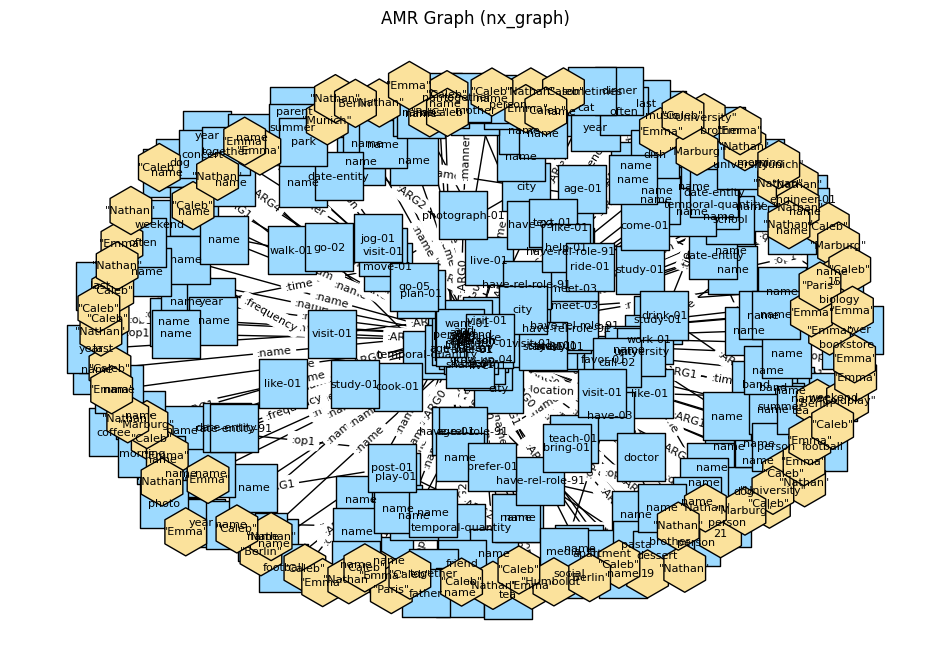

amr_graph.html
✅ Interactive graph written to amr_graph.html — open it in your browser or view inline below.


In [104]:
# --- visualize nx_graph ---
import matplotlib.pyplot as plt
from pyvis.network import Network

# Assign shapes and colors based on node type
for n, d in nx_graph.nodes(data=True):
    if d.get("kind") == "concept":
        d["shape"] = "square"
        d["color"] = "#9ddaff"
    elif d.get("kind") == "literal":
        d["shape"] = "hexagon"
        d["color"] = "#fbe29c"
    else:
        d["shape"] = "circle"
        d["color"] = "#cbe5b6"

# ---- Matplotlib static visualization ----
pos = nx.spring_layout(nx_graph, seed=42)
plt.figure(figsize=(12, 8))

for kind, shape in {"concept": "s", "literal": "h", "other": "o"}.items():
    nodes = [n for n, d in nx_graph.nodes(data=True) if d.get("kind") == kind]
    if nodes:
        nx.draw_networkx_nodes(
            nx_graph, pos, nodelist=nodes,
            node_shape=shape,
            node_color=[nx_graph.nodes[n]["color"] for n in nodes],
            node_size=1200, edgecolors="black"
        )

nx.draw_networkx_labels(nx_graph, pos,
                        labels={n: d.get("concept", n) for n, d in nx_graph.nodes(data=True)},
                        font_size=8)
nx.draw_networkx_edges(nx_graph, pos, arrows=True, arrowstyle="-|>")
nx.draw_networkx_edge_labels(nx_graph, pos,
                             edge_labels={(u, v): d.get("role", "") for u, v, d in nx_graph.edges(data=True)},
                             font_size=8)

plt.title("AMR Graph (nx_graph)")
plt.axis("off")
plt.show()

# ---- PyVis interactive visualization ----
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    net.add_node(n, label=d.get("concept", n),
                 color=d.get("color", "#cbe5b6"),
                 shape="box" if d.get("shape") == "square" else "ellipse",
                 title=f"id: {n}<br>kind: {d.get('kind', '')}")

for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html")
print("✅ Interactive graph written to amr_graph.html — open it in your browser or view inline below.")


In [95]:

# ---- PyVis interactive visualization ----
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    net.add_node(n, label=d.get("concept", n),
                 color=d.get("color", "#cbe5b6"),
                 shape="box" if d.get("shape") == "square" else "ellipse",
                 title=f"id: {n}<br>kind: {d.get('kind', '')}")

for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html", notebook=None)
print("✅ Interactive graph written to amr_graph.html — open it in your browser or view inline below.")


amr_graph.html
✅ Interactive graph written to amr_graph.html — open it in your browser or view inline below.


Each sentence converted to Sentence.py with all tokens in and tags like [Boilerplate] [Ambigous] or references like [1j123jS] = Main Device

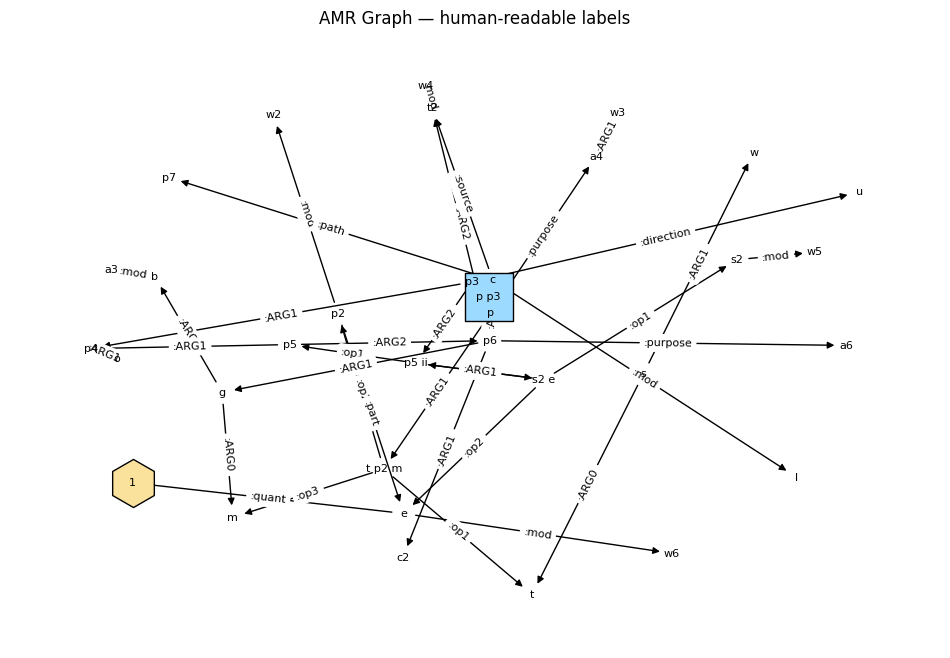

amr_graph.html
✅ Updated labels. Open amr_graph.html to explore interactively.


In [14]:
# --- Make node labels human-readable (use :name, :instance, :wiki) and re-render ---
from pyvis.network import Network
import re

# 1) Build helper maps from the PENMAN graph
inst = {s: t for s, r, t in g.triples if r == ":instance"}  # var -> concept

# Gather :name ops (op1/op2/...) and :wiki
name_parts = {}  # var -> [op1, op2, ...]
wiki = {}        # var -> "Qxxxx" or page

for s, r, t in g.triples:
    if r == ":wiki":
        wiki[s] = str(t).strip('"')
    elif r.startswith(":op"):
        # Only consider ops for nodes that have a :name relation
        # AMR often encodes names as: (x / person :name (n / name :op1 "John" :op2 "Doe"))
        # But in triple form, ops still reference the same source var as :name subtree var.
        name_parts.setdefault(s, []).append(str(t).strip('"'))
    elif r == ":name":
        # mark this var as having a name container; ops will attach to this var
        name_parts.setdefault(s, [])

# Also handle cases where name container is a separate var:
# If there are triples like (x :name n) and (n :op1 "Foo"), re-map ops from 'n' to 'x'.
name_container_edges = [(s, t) for s, r, t in g.triples if r == ":name"]
container_to_host = {container: host for host, container in name_container_edges}
if container_to_host:
    remap = {}
    for var, parts in list(name_parts.items()):
        if var in container_to_host:
            host = container_to_host[var]
            remap.setdefault(host, [])
            remap[host].extend(parts)
            del name_parts[var]
    for host, parts in remap.items():
        name_parts.setdefault(host, []).extend(parts)

# 2) Compute a pretty label for each node
def pretty_label(var_id, data):
    kind = data.get("kind")
    concept = data.get("concept", "")
    parts = name_parts.get(var_id, [])
    name_str = " ".join(parts).strip()
    if kind == "literal":
        return concept  # literal node already stores the text as 'concept'
    # Prefer explicit name if present
    if name_str:
        return name_str
    # Fall back to concept, title-case for readability (avoid overdoing for acronyms)
    if concept:
        # keep hyphens/underscores readable
        return re.sub(r"[_-]+", " ", str(concept)).strip()
    # Final fallback: the variable ID itself
    return str(var_id)

# 3) Attach labels, wiki, and root flag to nodes
root_var = getattr(g, "top", None)
for n, d in nx_graph.nodes(data=True):
    d["label"] = pretty_label(n, d)
    if n in wiki:
        d["wiki"] = wiki[n]
    if root_var is not None and n == root_var:
        d["root"] = True

# 4) Quick static check with matplotlib labels = node['label']
pos = nx.spring_layout(nx_graph, seed=7)
plt.figure(figsize=(12, 8))
for kind, shape in {"concept": "s", "literal": "h", "other": "o"}.items():
    nodes = [n for n, d in nx_graph.nodes(data=True) if d.get("kind") == kind]
    if nodes:
        nx.draw_networkx_nodes(
            nx_graph, pos, nodelist=nodes,
            node_shape=shape,
            node_color=[nx_graph.nodes[n].get("color", "#cbe5b6") for n in nodes],
            node_size=1200, edgecolors="black",
        )

nx.draw_networkx_edges(nx_graph, pos, arrows=True, arrowstyle="-|>")
nx.draw_networkx_labels(nx_graph, pos,
                        labels={n: d.get("label", n) for n, d in nx_graph.nodes(data=True)},
                        font_size=8)
nx.draw_networkx_edge_labels(nx_graph, pos,
                             edge_labels={(u, v): d.get("role", "") for u, v, d in nx_graph.edges(data=True)},
                             font_size=8)
plt.title("AMR Graph — human-readable labels")
plt.axis("off")
plt.show()

# 5) PyVis interactive with nice tooltips
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    hover = (
        f"<b>id</b>: {n}"
        f"<br><b>concept</b>: {d.get('concept','')}"
        f"<br><b>label</b>: {d.get('label','')}"
        + (f"<br><b>wiki</b>: {d.get('wiki')}" if d.get("wiki") else "")
        + (f"<br><b>root</b>: {d.get('root')}" if d.get("root") else "")
    )
    net.add_node(
        n,
        label=d.get("label", str(n)),
        title=hover,
        color=d.get("color", "#cbe5b6"),
        shape="box" if d.get("shape") == "square" else ("hexagon" if d.get("shape") == "hexagon" else "ellipse"),
    )

for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html" , notebook=None)
print("✅ Updated labels. Open amr_graph.html to explore interactively.")


In [14]:
import os, pyvis, jinja2, sys
print("pyvis:", pyvis.__version__, "->", pyvis.__file__)
print("jinja2:", jinja2.__version__)
# Check if the template exists on disk:
tmpl_dir = os.path.join(os.path.dirname(pyvis.__file__), "templates")
print("template dir exists:", os.path.isdir(tmpl_dir))
if os.path.isdir(tmpl_dir):
    print("has template.html:", os.path.isfile(os.path.join(tmpl_dir, "template.html")))


pyvis: 0.3.2 -> c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\pyvis\__init__.py
jinja2: 3.1.6
template dir exists: True
has template.html: True


In [ ]:
##traversing

